In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Creating gas-specific timeseries representing offseting in California cap-and-trade

This notebook uses data from the California Air Resources Board (CARB) to create two timeseries: 

(1) A `ca-project-fluxes` timeseries representing the actual fluxes associated with the offset credits that have been used for compliance purposes within the program. Project fluxes can be co2, ch4, or cfc-12. Fluxes are recorded in the timeseries according to credit vintage, which means they happen systematically later than experienced in the real world. 

(2) A `ca-justified-emission-fluxes` timeseries representing the fluxes associated with regulated polluters that have used offset credits within the program. Justified emissions can be co2, ch4, or n2o — the three gases that are reported to CARB by regulated polluters. 

Per program rules, these timeseries match on a cumulative CO2e basis. However, this obsures the effect of when the fluxes actually occur and what types of gases are involved in the offsetting transaction. Our goal is to explore these hidden dimensions of the program that affect it's net temperature effect over time. 

# Notebook-wide parameters and data

In [4]:
# CARB changed GWP-100 values in 2021. that change is reflected in the `column description` tab of the mrr data
# reports, as well as elsewhere in CARB documentation. that means when we're making any conversions between gas
# quantities and total co2e, we need to be thoughtful about which year's data we're manipulating. The CFC gwp is
# only relevant on the project emission side and was found in the protocols (2014 ODS protocol, Table B.1; 
# 2011 ODS protocol, Table 5.1).

gwp_values = {
    'co2':  {y: 1  for y in range(2013, 2025)},
    'ch4':  {**{y: 21 for y in range(2013, 2021)}, **{y: 25  for y in range(2021, 2025)}},
    'n2o':  {**{y: 310 for y in range(2013, 2021)}, **{y: 298 for y in range(2021, 2025)}},
    'cfc-12': {y: 10900  for y in range(2013, 2025)},
}

We'll use the latest CARB issuance table to construct both timeseries. This data includes per project information about (1) credit vintage, and (2) retirements per compliance period. 

In [5]:
# import raw offset use data and clean up column naming and data types
rename_issuance = {
    "OPR Project ID": "opr_id",
    "Project Type": "project_type",
    "Vintage": "vintage",
    "ARB Offset Credits Issued": "issuance",
    "Retired 1st Compliance Period (CA)": "compliance_1",
    "Retired 2nd Compliance Period (CA)": "compliance_2",
    "Retired 3rd Compliance Period (CA)": "compliance_3",
    "Retired 4th Compliance Period (CA)": "compliance_4",
    "Retired 5th Compliance Period (CA)": "compliance_5",
}
df_issuance = pd.read_excel('input-data/nc-arboc_issuance.xlsx', sheet_name='ARB Offset Credit Issuance', skiprows=0)
df_issuance = df_issuance[rename_issuance.keys()].rename(columns=rename_issuance)
df_issuance = df_issuance.dropna(subset=['vintage'])
df_issuance['vintage'] = df_issuance['vintage'].astype(int)

# print out total number of credits used for compliance purposes as a reference number
compliance_cols = ['compliance_1', 'compliance_2', 'compliance_3', 'compliance_4', 'compliance_5']
df_issuance['total_credits_used'] = df_issuance[compliance_cols].sum(axis=1)
df_issuance['total_credits_used'].sum()

167253813.0

We'll use the CARB mrr data reports to construct the justified emissions timeseries. This data includes per facility information about gas-specific emissions and total emissions (in co2e). 

In [6]:
# import raw mrr data and clean up column naming 
file_config_by_year = {
    "2013": {
        "file": "2013-ghg-emissions-2019-11-04.xlsx",
        "overview": "2013 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
        
    },
    "2014": {
        "file": "2014-ghg-emissions-2019-11-04.xlsx",
        "overview": "2014 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2015": {
        "file": "2015-ghg-emissions-2019-11-04.xlsx",
        "overview": "2015 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2016": {
        "file": "2016-ghg-emissions-2022-11-04.xlsx",
        "overview": "2016 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2017": {
        "file": "2017-ghg-emissions-2022-11-04.xlsx",
        "overview": "2017 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2018": {
        "file": "2018-ghg-emissions-2022-11-04.xlsx",
        "overview": "2018 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2019": {
        "file": "2019-ghg-emissions-2023-11-06.xlsx",
        "overview": "2019 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "",
    },
    "2020": {
        "file": "2020-ghg-emissions-2024-11-15.xlsx",
        "overview": "2020 GHG Data",
        "skiprows_overview": 8,
        "ghgs": "2020 Emissions by GHG",
        "skiprows_ghg": 6,
    },
    "2021": {
        "file": "2021-ghg-emissions-2023-11-06.xlsx",
        "overview": "2021 GHG Data",
        "skiprows_overview": 9,
        "ghgs": "2021 Emissions by GHG",
        "skiprows_ghg": 6,
    },
    "2022": {
        "file": "2022-ghg-emissions_2025_11_04.xlsx",
        "overview": "2022 GHG Data",
        "skiprows_overview": 7,
        "ghgs": "2022 Emissions by GHG",
        "skiprows_ghg": 6,
    },
     "2023": {
        "file": "2023-ghg-emissions_2025_11_04.xlsx",
        "overview": "2023 GHG Data",
        "skiprows_overview": 7,
        "ghgs": "2023 Emissions by GHG",
        "skiprows_ghg": 5,
    },
      "2024": {
        "file": "2024-ghg-emissions-2025-11-04.xlsx",
        "overview": "2024 GHG Data",
        "skiprows_overview": 7,
        "ghgs": "2024 Emissions by GHG",
        "skiprows_ghg": 5,
    },
}

rename_overview = {
    "ARB ID": "facility_id",
    "Report\nYear": "year",
    "Facility Name": "facility_name",
    "City": "city",
    "State": "state",
    "Industry Sector": "sector",
    "Total CO2e \n(combustion, process, vented, and supplier)": "total_co2e",
    "Total Covered Emissions": "total_covered_co2e",
    "Total Non-Covered Emissions ": "total_non_coverned_co2e"
}

rename_ghgs = {
    "ARB ID": "facility_id",
    "CO2": "co2",
    " CH4": "ch4",
    "N2O": "n2o"
}

years = [str(y) for y in range(2013, 2025)]

# silence warnings about excel features (e.g. dropdowns) that aren't recognized
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
dfs = []
for year in years: 
    
    # read and clean-up overview data tab
    df_overview = pd.read_excel("input-data/mrr-data/" + file_config_by_year[year]['file'], sheet_name=file_config_by_year[year]['overview'], skiprows=file_config_by_year[year]['skiprows_overview'])
    df_overview = df_overview[rename_overview.keys()].rename(columns=rename_overview)
    
    # read and clean-up ghg data tab, if available
    if file_config_by_year[year]['ghgs']:
        df_ghgs = pd.read_excel("input-data/mrr-data/" + file_config_by_year[year]['file'], sheet_name=file_config_by_year[year]['ghgs'], skiprows=file_config_by_year[year]['skiprows_ghg'])
        df_ghgs = df_ghgs[rename_ghgs.keys()].rename(columns=rename_ghgs)
    else:
        df_ghgs = pd.DataFrame(columns=rename_ghgs.values())
    
    # combine the two tabs of data and add to df list
    merged_df = pd.merge(df_overview, df_ghgs, on='facility_id', how='left')
    dfs.append(merged_df)

df_mrr = pd.concat(dfs, ignore_index=True)

We'll use the CARB compliance reports to construct the justified emissions timeseries. This data includes per entity information about which facilities are associated with the entity, and the entity's use of offsets for compliance.

In [7]:
# import compliance report data and clean up columns 
compliance_config_by_year = {
    "2014": {
        "file": "2013-2014compliancereport.xlsx",
        "compliance_summary": "2013-2014 Compliance Summary",
        "skiprows": 4    
    },
    "2017": {
        "file": "2015-2017compliancereport.xlsx",
        "compliance_summary": "2015-2017 Compliance Summary",
        "skiprows": 4
    },
    "2020": {
        "file": "nc-2018-2020compliancereport.xlsx",
        "compliance_summary": "2018-2020 Compliance Summary",
        "skiprows": 4
    },
    "2023": {
        "file": "nc-CP4compliancereport.xlsx",
        "compliance_summary": "CP4 Compliance Summary",
        "skiprows": 4
    },
    "2024": {
        "file": "nc-2024compliancereport.xlsx",
        "compliance_summary": "2024 Compliance Summary",
        "skiprows": 4
    },
}

year_to_report = { 
    "2013": "2014",
    "2014": "2014",
    "2015": "2017",
    "2016": "2017",
    "2017": "2017",
    "2018": "2020",
    "2019": "2020",
    "2020": "2020",
    "2021": "2023",
    "2022": "2023",
    "2023": "2023",
    "2024": "2024",
}

rename_compliance_summary = {
    "Entity ID": "entity_id", 
    "ARB GHG ID": "facility_ids",
    "Total Offsets Surrendered": "offsets_surrendered"
}

# import raw compliance report data
dfs = []
for report_year, config in compliance_config_by_year.items():
    df = pd.read_excel( "input-data/compliance-reports/" + config['file'], sheet_name=config['compliance_summary'], skiprows=config['skiprows'])
    df.columns = df.columns.str.strip()
    df = df[rename_compliance_summary.keys()].rename(columns=rename_compliance_summary)
    df['year'] = report_year
    df = df.dropna(subset=['entity_id'])
    dfs.append(df)
df_compliance = pd.concat(dfs, ignore_index=True)

# there are several instances in the first compliance period (CA.., CA1000) where the report has a
# has a manually corrected offsets_surrendered value that's crossed out and replaced in the same cell; we
# are onyl keeping the updated values
df_compliance.loc[df_compliance['offsets_surrendered'] == '398,720  409,876', 'offsets_surrendered'] =  409876
df_compliance.loc[df_compliance['offsets_surrendered'] == '1,393,592  1,407,506', 'offsets_surrendered'] = 1407506
df_compliance.loc[df_compliance['offsets_surrendered'] == '24,427 24,651', 'offsets_surrendered'] = 24651

# Creating `project-fluxes` timeseries

All credits corresponds to 1 tCO2e. To translate that into gas-specific offset project fluxes, we  need to make assumptions on a project type, protocol, or maybe even project-specific basis. We're going to cast all of these fluxes as negative fluxes to represent removal (or avoidance) in comparison to the baseline.

Method: 
- Forest — assume all credits correspond to a negative CO2 flux, and an efflux corresponding with the end of the permanence period (100 years)
- MMC — assume all credits correspond to a negative CH4 flux
- Livestock — assume all credits correspond to a negative CH4 flux
- ODS — that all ODS projects translate to CFC-12 reductions; consider project-specific classification

Problems: 
- Obscures the fact that within any project, there is gwp logic happening to net out project emissions 
- Obscures the fact that for some project types, there may be a reduction in multiple gas types

In [8]:
working_df = df_issuance.copy()
working_df['project_type'].unique()

array(['ODS', 'MMC', 'Forest', 'Livestock'], dtype=object)

In [154]:
# assume all forest credit compliance use translate to CO2 emission reductions
forest_mask = working_df['project_type'] == 'Forest'
working_df.loc[forest_mask, 'co2_flux'] = working_df.loc[forest_mask, 'total_credits_used'] * -1

# assume all forest carbon storage reverses 100 years after credit issuance 
reemission_rows = working_df[forest_mask][['opr_id', 'project_type', 'vintage', 'co2_flux']].copy()
reemission_rows['vintage'] = reemission_rows['vintage'] + 100
reemission_rows['co2_flux'] = reemission_rows['co2_flux'] * -1
working_df = pd.concat([working_df, reemission_rows], ignore_index=True)

In [155]:
# assume all MMC credit compliance use translate to CH4 emission reductions
mmc_mask = working_df['project_type'] == 'MMC'
working_df.loc[mmc_mask, 'ch4_flux'] = (
    working_df.loc[mmc_mask, 'total_credits_used'] / 
    working_df.loc[mmc_mask, 'vintage'].map(gwp_values['ch4'])
) * -1

In [156]:
# assume all Livestock compliance use translate to CH4 emission reductions
livestock_mask = working_df['project_type'] == 'Livestock'
working_df.loc[livestock_mask, 'ch4_flux'] = (
    working_df.loc[livestock_mask, 'total_credits_used'] / 
    working_df.loc[livestock_mask, 'vintage'].map(gwp_values['ch4'])
) * -1

In [157]:
# assume that all ODS projects translate to CFC-12 reductions
# looked at top 10 ODS projects with retirements; ODPR section VI reports "ODS DESTROYED" by mass 
# all projects had a mix of gases, but all had a majority (>95%) CFC-12
ods_mask = working_df['project_type'] == 'ODS'
working_df.loc[ods_mask, 'cfc-12_flux'] = (
    working_df.loc[ods_mask, 'total_credits_used'] / 
    working_df.loc[ods_mask, 'vintage'].map(gwp_values['cfc-12'])
) * -1

# TODO: should we do project-level classification using ODPRS? there are only about 300 projects, 
# and eight eligible ODS substances to destroy, each will quite distinct GWP and all captured in FaIR.
# (see the 2014 ODS protocol, Section 2.2 and Tables B.1 and B.2)

We can group by year to create timeseries of ghgs that were used to offset the ongoing emissions of regulated polluters, and export to a csv. 


In [159]:
project_fluxes = working_df.groupby('vintage')[['ch4_flux', 'co2_flux', 'cfc-12_flux','total_credits_used']].sum().reset_index()
project_fluxes = project_fluxes.rename(columns={'vintage': 'year'})
project_fluxes.to_csv('output-data/ca_project_fluxes.csv', index=False)

# Create `justified-emission-fluxes` timeseries

We know that all offset credits used for compliance purposes justify 1 tCO2e emissions. To translate that into gas-specific justified emissions, we need to bring in additional data about who is using offsets and what their gas-specific emission profile is. We're going to break this down into three steps: 

1. Calculate facility-level gas proportions by year (using MRR data)
2. Aggregate to entity-level gas proportions by year (using compliance reports) 
3. Aggregate to gas-specific offset-justified emissions by year (using compliance reports and issuance table) 

The resulting timeseries of fluxes will be positive to represent emissions in comparison to the baseline.

### Step 1: Calculate facility-level gas proportions by year

We have gas-specific emissions data per facility from 2020 onwards in the annual MRR data reports. We can use this to calculate annual "gas proportions" associated with each facility. 

Method: 
- For each facility, calculate the gas proportion as: `(facility reported gas quantity * year-specific gwp value) / total facility emissions in co2e`. 
- Since gas-specific emissions are only reported from 2020 onwards, we have to back-cast the average facility-specific proportions to prior years. 
- The resulting data frame will have total emissions and gas proportions per facility per year: `facility_id`, `year`, `co2_proportion`, `ch4_proportion`, `n2o_proportion`, and `total_co2e`. 

Problems: 
- Back-casting average reported gas proportions could be a problem for a number of reasons, including the possibility that a facility's fuel mix or process changed between 2013-2019 and 2020-2024.

In [60]:
working_df = df_mrr.copy()

# drop facilities that reported no total emissions or no covered emissions
working_df = working_df[working_df['total_co2e'] > 0]
working_df = working_df[working_df['total_covered_co2e'] > 0]

# subset to columns of interest
working_df = working_df[['facility_id', 'year', 'total_co2e', 'co2', 'ch4', 'n2o']]

In [61]:
# calculate facility-level gas proportions
for gas in ['co2', 'ch4', 'n2o']:
    working_df[f'{gas}_proportion'] = (working_df[gas] * 
                                       working_df['year'].map(gwp_values[gas])
                                      )/ working_df['total_co2e']

# calculate average proportions per facility from 2020 onwards
avg_proportions = (
    working_df[working_df['year'] >= 2020]
    .groupby('facility_id')[['co2_proportion', 'ch4_proportion', 'n2o_proportion']]
    .mean()
)

# backfill pre-2020 rows with facility-specific averages
pre_2020_mask = working_df['year'] < 2020
for gas in ['co2', 'ch4', 'n2o']:
    working_df.loc[pre_2020_mask, f'{gas}_proportion'] = (
        working_df.loc[pre_2020_mask, 'facility_id'].map(avg_proportions[f'{gas}_proportion'])
    )    

# apply average proportions to post-2020 rows when there is an average to apply but that year had no data 
post_2020_na_mask = (working_df['year'] > 2020) & (working_df['co2_proportion'].isna())
for gas in ['co2', 'ch4', 'n2o']:
    working_df.loc[post_2020_na_mask, f'{gas}_proportion'] = (
        working_df.loc[post_2020_na_mask, 'facility_id'].map(avg_proportions[f'{gas}_proportion'])
    )
    
# if there is no average to backfill with, assume all emissions were co2 
working_df[['co2_proportion', 'ch4_proportion', 'n2o_proportion']] = (
    working_df[['co2_proportion', 'ch4_proportion', 'n2o_proportion']]
    .fillna({'co2_proportion': 1, 'ch4_proportion': 0, 'n2o_proportion': 0})
)

In [62]:
facility_gas_proportions = working_df[['facility_id', 'year', 'total_co2e', 
                                       'co2_proportion', 'ch4_proportion', 'n2o_proportion']]

In [64]:
# as check, on this final dataframe we produced, we can compare how many unique facilities we capture
# as compared to the raw mrr data. we're dropping anywhere from 67 to 113 facilities in each year because 
# they don't report any total emissions, and twice that much because they don't report emissions >0 or 
# don't have covered emissions

comparison = pd.DataFrame({
    'facility_gas_proportions': facility_gas_proportions.groupby('year')['facility_id'].nunique(),
    'df_mrr': df_mrr.groupby('year')['facility_id'].nunique(), 
})
comparison['diff'] = comparison['facility_gas_proportions'] - comparison['df_mrr']
comparison

,facility_gas_proportions,df_mrr,diff
year,,,
2013,435,785,-350
2014,441,806,-365
2015,415,814,-399
2016,417,809,-392
2017,420,810,-390
2018,405,821,-416
2019,407,817,-410
2020,413,837,-424
2021,386,835,-449


### Step 2: Aggregate to entity-level gas proportions by year

We can map facilities to compliance entities using the compliance reports, and then use that to create a picture of entity level gas proportions and offset use by year. 

Method:
- Map facilities to entities
- Calculate the entity-level gas proportions by combining on entity id, and weighting each facility-level proportion by facility-level total emissions. 
- Record the entity-level offset use, dividing reported offset use evenly over the compliance period. 
- The resulting dataframe will have: `entity_id`, `year`, `co2_proportion`, `ch4_proportion`, `n2o_proportion`, `offset_use`. 

Problems: 
- Dropping facilities that report emissions but aren't mapped to a compliance entity. (TK) 
- Dividing offset use evenly across years to represent the quantity of offset-justified emissions is an assumption / simplification. 

In [128]:
# create an "exploded" compliance data frame that has a row for every entity-facility-year combination
compliance_exploded = df_compliance.copy()
print(f"start: {compliance_exploded['entity_id'].nunique()} entities")

# split the year column from the compliance data so there's one row for every compliance period 
# (e.g. 2013 and 2014 instead of just 2014)
compliance_exploded['year'] = compliance_exploded['year'].map(compliance_periods)
compliance_exploded = compliance_exploded.explode('year')
compliance_exploded['year'] = compliance_exploded['year'].astype(int)
print(f"after year: {compliance_exploded['entity_id'].nunique()} entities")

# split the facility_ids column from the compliance data and explode to one row per facility
# not splitting offsets_surrendered here, since we'll re-aggregate by entity
compliance_exploded['facility_id'] = compliance_exploded['facility_ids'].astype(str).str.split(', ')
compliance_exploded = compliance_exploded.explode('facility_id')
compliance_exploded = compliance_exploded[compliance_exploded['facility_id'] != 'nan']
compliance_exploded['facility_id'] = compliance_exploded['facility_id'].astype(int)
compliance_exploded = compliance_exploded.drop(columns=['facility_ids'])
print(f"after facility: {compliance_exploded['entity_id'].nunique()} entities")

start: 711 entities
after year: 711 entities
after facility: 709 entities


In [129]:
working_df = facility_gas_proportions.copy()

# pre-merge counts
print(f"facility_gas_proportions: {facility_gas_proportions['facility_id'].nunique()} facilities")
print(f"compliance_exploded: {compliance_exploded['facility_id'].nunique()} facilities, {compliance_exploded['entity_id'].nunique()} entities")
print("")

# merge to create a combined df
working_df = working_df.merge(
    compliance_exploded[['facility_id', 'entity_id', 'year','offsets_surrendered']].drop_duplicates(),
    on=['facility_id', 'year'],
    how='inner'
)

# post-merge counts
print(f"working_df: {working_df['facility_id'].nunique()} facilities, {working_df['entity_id'].nunique()} entities")

# facilities lost in merge
lost_facilities = set(facility_gas_proportions['facility_id']) - set(working_df['facility_id'])
print(f"facilities dropped in merge: {len(lost_facilities)}")
print("")

# entity_gas_proportions
entity_gas_proportions = (
    working_df.groupby(['entity_id', 'year'])
    .apply(lambda g: pd.Series({
        'co2_proportion': (g['co2_proportion'] * g['total_co2e']).sum() / g['total_co2e'].sum(),
        'ch4_proportion': (g['ch4_proportion'] * g['total_co2e']).sum() / g['total_co2e'].sum(),
        'n2o_proportion': (g['n2o_proportion'] * g['total_co2e']).sum() / g['total_co2e'].sum(),
        'total_co2e': g['total_co2e'].sum(),
        'offsets_used': g['offsets_surrendered'].iloc[0]
    }))
    .reset_index()
)

# post-groupby checks
print(f"entity_gas_proportions: {entity_gas_proportions['entity_id'].nunique()} entities")

facility_gas_proportions: 545 facilities
compliance_exploded: 546 facilities, 709 entities

working_df: 541 facilities, 708 entities
facilities dropped in merge: 4

entity_gas_proportions: 708 entities


In [81]:
# for peace of mind, we can check what facilities and entities we're dropping during the merge

# facility_ids dropped from compliance reports don't show up anywhere in mrr data. a couple of these 
# we've previously confirmed with CARB are typos 95755 and 5043). the other three are facilities that
# had no covered emissions and were therefore dropped in the creation of facility_gas_proportions.
print(set(compliance_exploded['facility_id']) - set(facility_gas_proportions['facility_id']))

# facility_ids dropped from the facility_gas_proprtions / mrr dataset all appear to  be transportation 
# fuel suppliers. i think they have different rules? TODO: look into this more
print(set(facility_gas_proportions['facility_id']) - set(compliance_exploded['facility_id']))

# the single entity dropped is associated with a single facility that has no covered emissions 
# (see 2018-2020 compliance report)
print(set(compliance_exploded['entity_id']) - set(working_df['entity_id']))

{57555, 100884, 5043, 104759, 104543}
{104002, 104517, 104070, 104623}
{'CA3078'}


In [138]:
# rectify the offset numbers, so each entity-compliance period total offset number isn't replicated across 
# multiple rows

period_to_reporting_year = {2013: '2014', 2014: '2014', 2015: '2017', 2016: '2017', 2017: '2017',
                             2018: '2020', 2019: '2020', 2020: '2020', 2021: '2023', 2022: '2023',
                             2023: '2023', 2024: '2024'}
entity_gas_proportions['reporting_year'] = entity_gas_proportions['year'].map(period_to_reporting_year)

# count how many years each entity appears in each compliance period
entity_gas_proportions['years_in_period'] = entity_gas_proportions.groupby(['entity_id', 'reporting_year'])['year'].transform('nunique')

# get full period offsets from df_compliance and divide by surviving years
offsets_lookup = df_compliance.set_index(['entity_id', 'year'])['offsets_surrendered'].astype(float).to_dict()
entity_gas_proportions['offsets_used'] = entity_gas_proportions.apply(
    lambda r: offsets_lookup.get((r['entity_id'], r['reporting_year']), 0) / r['years_in_period'], axis=1
)

# drop extra process columns
entity_gas_proportions = entity_gas_proportions.drop(columns=['reporting_year', 'years_in_period'])

# check if  we correctly preserved reported offset_use 
print(df_compliance['offsets_surrendered'].sum() - entity_gas_proportions['offsets_used'].sum())

0.0


In [137]:
# note that the total_co2 here is the sum of total co2e reported by each associated facility in the mrr data.
# it is much higher that the "emissions obligation", "compliance obligation" or "instruments surrendered" in the 
# compliance reports. see CA2364 (Marathon) in 2024 as an example, which has three associated facilities. the total
# emissions for these facilities reported in the 2024 mrr report is ~40,257,510, whereas the entity's total
# emissions obligation is 34,436,236, which corresponds to the sum of facility-level covered emissions. this doesn't
# really matter for us, since we're not going to use the total_co2e number moving forwar. just connecting dots... 

entity_gas_proportions

,entity_id,year,co2_proportion,ch4_proportion,n2o_proportion,total_co2e,offsets_used
0,CA1000,2013,1.000000,0.000000,0.000000,124436.923254,8800.0
1,CA1000,2014,1.000000,0.000000,0.000000,130442.808200,8800.0
2,CA1000,2015,1.000000,0.000000,0.000000,81051.717616,0.0
3,CA1000,2016,1.000000,0.000000,0.000000,173.120864,0.0
4,CA1001,2013,0.998978,0.000456,0.000566,23876.394956,0.0
...,...,...,...,...,...,...,...
3377,CA4038,2024,1.000000,0.000000,0.000000,950.443507,0.0
3378,CA4041,2024,0.995987,0.001186,0.002827,5092.893438,0.0
3379,CA4045,2024,0.998967,0.000471,0.000561,47600.914580,0.0
3380,CA4062,2024,0.998967,0.000471,0.000561,26382.920490,0.0


### Step 3: Convert to offset-justified emissions per year

With these data inputs — and some cross checking with the offset-use data in the issuance table — we can calculate of the gas-specific emissions that are justified using offsets on an annual basis. 

Method: 
- Drop all entities who use no offsets in a given year. 
- Scale compliance report offset use data in compliance period 1 to conservatively match the data from the issuance table. 
- Calculate the quantity of offset-justified gases for each entity in each year with the following formula: `(gas proportion * annual offset use) / year-specific gwp value`
- Aggregate by year to get a timeseries of gas-specific emissions justified by offset use. 
- The resulting dataframe will have: `year`, `co2`, `n2o`, `ch4`, `original-offset-use`, `corrected-offset-use`

Problems: 
- The issuance table and compliance reports disagree about how many offset have been used for compliance purposes, but only in the first compliance period. We are going to use the issuance table value since is is lower and therefore more conservative. Right now, we're just scaling all compliance period 1 values with the factor: `(issuance table offset use / compliance report offset use)`, but it's probably worth some more digging to find a better fix. (E.g. maybe the problem is just with one entity or project?)

In [139]:
working_df = entity_gas_proportions.copy()

# drop entities with no offset use
working_df = working_df[working_df['offsets_used'] > 0]

In [141]:
# calculate compliance period 1 scaling factor
cp1_compliance = df_compliance[df_compliance['year'] == '2014']['offsets_surrendered'].astype(float).sum()
cp1_issuance = df_issuance['compliance_1'].sum()
cp1_scale_factor = cp1_issuance / cp1_compliance

# apply scaling factor to compliance period 1 years
working_df.loc[working_df['year'] <= 2014, 'offsets_used_corrected'] = (
    working_df.loc[working_df['year'] <= 2014, 'offsets_used'] * cp1_scale_factor)
working_df['offsets_used_corrected'] = working_df['offsets_used_corrected'].fillna(working_df['offsets_used'])

# check that overall offset use matches now 
print(working_df['offsets_used_corrected'].sum() - df_issuance['total_credits_used'].sum())

0.0


In [143]:
# calculate the quantity of offset-justified gases for each entity in each year
working_df['co2_justified'] = (working_df['co2_proportion'] * working_df['offsets_used_corrected']) / working_df['year'].map(gwp_values['co2'])
working_df['ch4_justified'] = (working_df['ch4_proportion'] * working_df['offsets_used_corrected']) / working_df['year'].map(gwp_values['ch4'])
working_df['n2o_justified'] = (working_df['n2o_proportion'] * working_df['offsets_used_corrected']) / working_df['year'].map(gwp_values['n2o'])

In [151]:
justified_emission_fluxes = working_df.groupby('year')[['co2_justified', 'ch4_justified', 'n2o_justified','offsets_used', 'offsets_used_corrected']].sum().reset_index()
justified_emission_fluxes.to_csv('output-data/ca_justified_emissions_fluxes.csv', index=False)

# Compare the two timeseries

In [162]:
# just to triple check, the total co2e volume of both timeseries should be the same 
print(project_fluxes['total_credits_used'].sum())
print(justified_emission_fluxes['offsets_used_corrected'].sum())

167253813.0
167253812.99999997


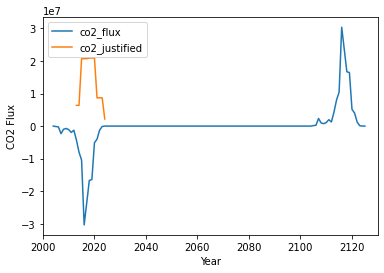

In [172]:
# but the gas-specific volumes should differ. co2 is almost the same... barring the limited permanence of 
# forest offsets
ax = project_fluxes.plot(x='year', y='co2_flux')
justified_emission_fluxes.plot(x='year', y='co2_justified', ax=ax)
plt.xlabel('Year')
plt.ylabel('CO2 Flux')
plt.xlim(2000, 2130)
plt.show()

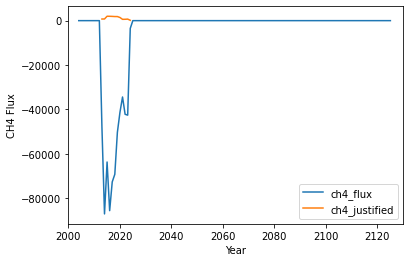

In [169]:
# ch4 offet credits far outweigh ch4 justified emissions, meaning ch4 is being used to justify 
# co2 — the trade that i expect will drive whatever interesting temperature dynamics result from the program
ax = project_fluxes.plot(x='year', y='ch4_flux')
justified_emission_fluxes.plot(x='year', y='ch4_justified', ax=ax)
plt.xlabel('Year')
plt.ylabel('CH4 Flux')
plt.xlim(2000, 2130)
plt.show()

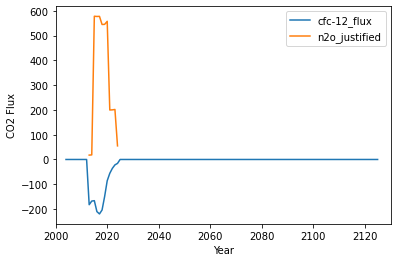

In [170]:
# n20 emissions and cfc-12 reductions are both happening on a much smaller scale, but might still be 
# interesting still because of their potency and n2o's relatively long lifetime
ax = project_fluxes.plot(x='year', y='cfc-12_flux')
justified_emission_fluxes.plot(x='year', y='n2o_justified', ax=ax)
plt.xlabel('Year')
plt.ylabel('CO2 Flux')
plt.xlim(2000, 2130)
plt.show()

# Deprecated  / scratch

## Test understanding of the emissions data

In this section, we test our understanding of the raw data. Specifically, for the years where both total emissions (CO2e) and gas specific emissions are reported, do the GWP converted values match? And for all years, is the sum of covered and uncovered emissions match the reported total emissions? 

Learnings: 
- GWP values switched in 2021. Converting between gas specific emissions and total emissions in co2e must happen with those year-specific values. 
- There are many small differences (<1 tCO2e) between total emissions and covered+uncovered. The only substantial differences are in 2021. Still getting to the bottom of those... 

In [14]:
# calculate difference between the sum of the the individual gas columns * gwp values and total emissions (co2e)
# when using year-dependent gwp values, there are no differences

differences = (
    combined_df
    .assign(
        difference=lambda x: ((x['total_co2e']) - (
            x['co2'] + 
            x['ch4'] * x['report_year'].apply(lambda y: gwp_values_2020_prior["ch4"] if y <= 2020 else gwp_values_2021_onwards["ch4"]) + 
            x['n2o'] * x['report_year'].apply(lambda y: gwp_values_2020_prior["n2o"] if y <= 2020 else gwp_values_2021_onwards["n2o"])
        )).round(2)
    )
)[['facility_id', 'report_year', 'total_co2e', 'co2', 'ch4', 'n2o', 'difference']]

differences[differences['difference'] > 0].groupby('report_year')['facility_id'].count()

Series([], Name: facility_id, dtype: int64)

In [15]:
# calculate difference between the sum of covered+uncovered and the total emissions

total_differences = (
    combined_df
    .assign(
        difference=lambda x: ((x['total_covered_co2e'] + x['total_non_coverned_co2e']) - 
                             (x['total_co2e'])).round(2)
    )
)[['facility_id', 'report_year', 'total_co2e', 'total_covered_co2e', 'total_non_coverned_co2e', 'difference']]

total_differences[total_differences['difference'] > 1].groupby('report_year')['facility_id'].count()

report_year
2021    2
Name: facility_id, dtype: int64

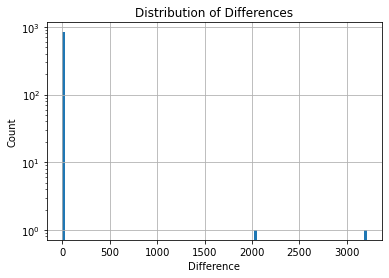

,facility_id,report_year,total_co2e,total_covered_co2e,total_non_coverned_co2e,difference
6890,104099,2021,47712.163216,50922.0,0.0,3209.84
7166,3081,2021,279519.369415,281568.0,0.0,2048.63


In [16]:
year = 2021

total_differences[total_differences['report_year'] == year]['difference'].hist(bins=100, log=True)
plt.xlabel('Difference')
plt.ylabel('Count')
plt.title('Distribution of Differences')
plt.show()

total_differences.reindex(total_differences[total_differences['report_year'] == year]['difference'].abs().sort_values(ascending=False).index).head(2)

^ As of 4/6, the only weirdness in comparing total emissions to covered+uncovered seems to be in the 2021 data. Both facilities are electricity importers where the `electricity importer covered emissions` > `electricity importer co2e`. 

## Random numbers

In [24]:
# Transcribed from compliance report "totals" reported at the bottom of the compliance summary tab

offset_use_compliance_report = {
    "2013-2014": 12798167,
    "2015-2017": 62717868,
    "2018-2020": 63355073,
    "2021-2023": 26211583,
    "2024": 2196192,
}

# Transcribed from each issuance table; sum of each compliance period column

offset_use_issuance_table = {
    "2013-2014": 12773097,
    "2015-2017": 62717868,
    "2018-2020": 63355073,
    "2021-2023": 26211583,
    "2024": 2196192,
}

# Difference fully concentrated in the first issuance period

print (offset_use_compliance_report['2013-2014']-offset_use_issuance_table['2013-2014'])

25070


## Offset use by project type

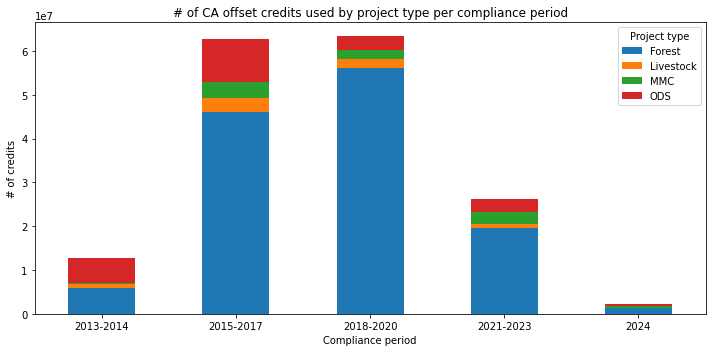

In [23]:
compliance_cols = ['compliance_1', 'compliance_2', 'compliance_3', 'compliance_4', 'compliance_5']
period_labels   = ['2013-2014', '2015-2017', '2018-2020', '2021-2023', '2024']

melted = df_issuance.melt(
    id_vars='project_type',
    value_vars=compliance_cols,
    var_name='period',
    value_name='credits'
)

period_credits = melted.groupby(['period', 'project_type'])['credits'].sum().unstack(fill_value=0)
# period_shares = period_shares.div(period_shares.sum(axis=1), axis=0)
period_credits.index = period_labels

period_credits.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.xlabel("Compliance period")
plt.ylabel("# of credits")
plt.title("# of CA offset credits used by project type per compliance period")
plt.legend(title="Project type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

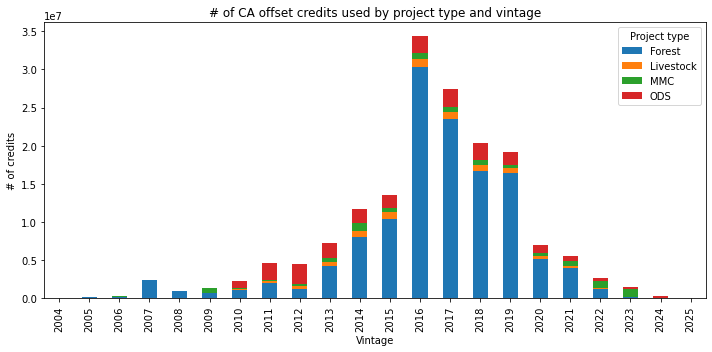

In [27]:
vintages = (
    df_issuance.groupby(['vintage', 'project_type'])['total_credits_used']
    .sum()
    .unstack(fill_value=0)
)

vintages.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.xlabel("Vintage")
plt.ylabel("# of credits")
plt.title("# of CA offset credits used by project type and vintage")
plt.legend(title="Project type")
plt.tight_layout()
plt.show()

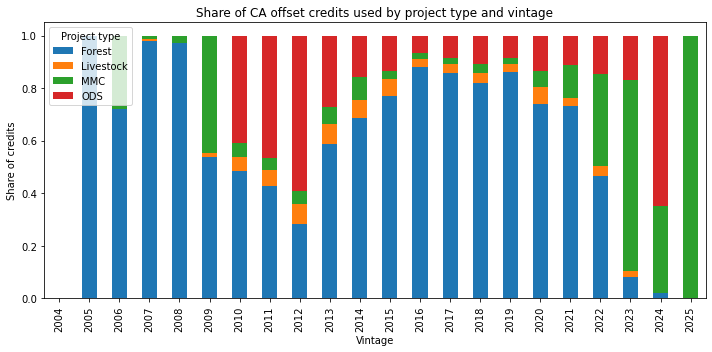

In [26]:
shares = (
    df_issuance.groupby(['vintage', 'project_type'])['total_credits_used']
    .sum()
    .unstack(fill_value=0)
)
shares = shares.div(shares.sum(axis=1), axis=0)  # normalize to shares

shares.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.xlabel("Vintage")
plt.ylabel("Share of credits")
plt.title("Share of CA offset credits used by project type and vintage")
plt.legend(title="Project type")
plt.tight_layout()
plt.show()

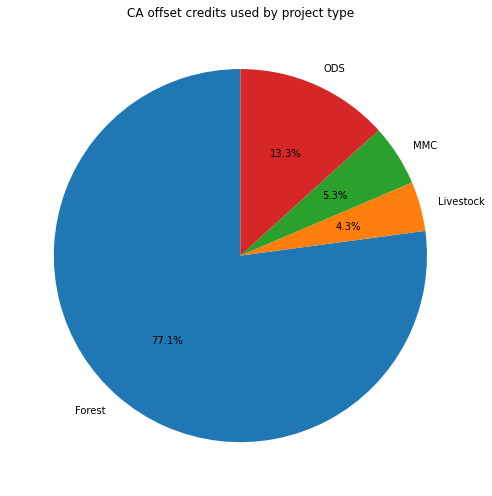

In [15]:
total_by_type = working_df.groupby('project_type')['total_credits_used'].sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(total_by_type, labels=total_by_type.index, autopct='%1.1f%%', startangle=90)
ax.set_title("CA offset credits used by project type")
plt.tight_layout()
plt.show()